<a href="https://colab.research.google.com/github/sanjaymaharja/Machine-Learning-Programming/blob/main/Project%3A%20Smart%20Health%20%26%20Lifestyle%20Prediction%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# ACTIVITY PART 1 — Load & Explore Dataset
# ============================================

# TODO 1: Loading dataset using pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Loading dataset
df = pd.read_csv('project_health_dataset.csv')

# TODO 2: Preview first 5 rows
print("="*60)
print("FIRST 5 ROWS OF DATASET:")
print("="*60)
print(df.head())
print("\n")

# TODO 3: Checking dataset info, missing values, duplicates
print("="*60)
print("DATASET INFORMATION:")
print("="*60)
print(df.info())
print("\n")

print("="*60)
print("MISSING VALUES CHECK:")
print("="*60)
print(df.isnull().sum())
print("\n")

print("="*60)
print("DUPLICATES CHECK:")
print("="*60)
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print("\n")

# TODO 4: Describing statistical summary of numerical features
print("="*60)
print("STATISTICAL SUMMARY:")
print("="*60)
print(df.describe())
print("\n")

FIRST 5 ROWS OF DATASET:
   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  


DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore      100 non-null

In [2]:
# ============================================
# ACTIVITY PART 2 — Data Cleaning & Feature Engineering
# ============================================

# TODO 5: Filling missing numerical values with mean
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# TODO 6: Filling missing categorical values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)

# TODO 7: Removing duplicates
df.drop_duplicates(inplace=True)

print("="*60)
print("DATA CLEANING COMPLETE")
print("="*60)
print(f"Dataset shape after cleaning: {df.shape}")
print("\n")

# TODO 8: Creating new features
# WellnessIndex = HoursExercise * HoursSleep
df['WellnessIndex'] = df['HoursExercise'] * df['HoursSleep']

# BMI Category function
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# TODO 9: Encoding categorical variables
# Encode Gender
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

# Encoding BMI Category
le_bmi = LabelEncoder()
df['BMI_Category_Encoded'] = le_bmi.fit_transform(df['BMI_Category'])

print("="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"New features added: WellnessIndex, BMI_Category")
print(f"Encoded features: Gender_Encoded, BMI_Category_Encoded")
print("\n")

DATA CLEANING COMPLETE
Dataset shape after cleaning: (100, 8)


FEATURE ENGINEERING COMPLETE
New features added: WellnessIndex, BMI_Category
Encoded features: Gender_Encoded, BMI_Category_Encoded




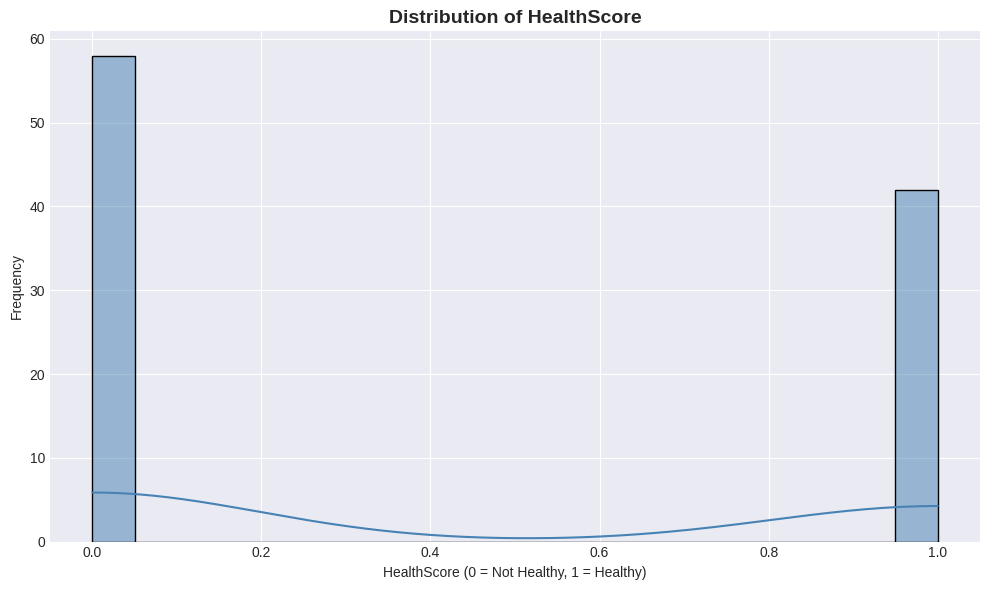

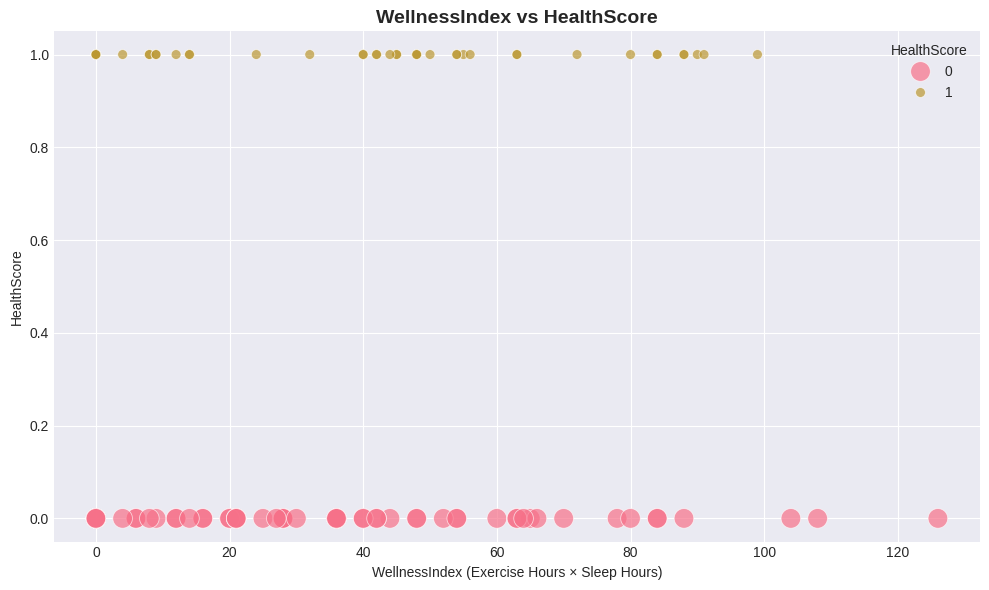

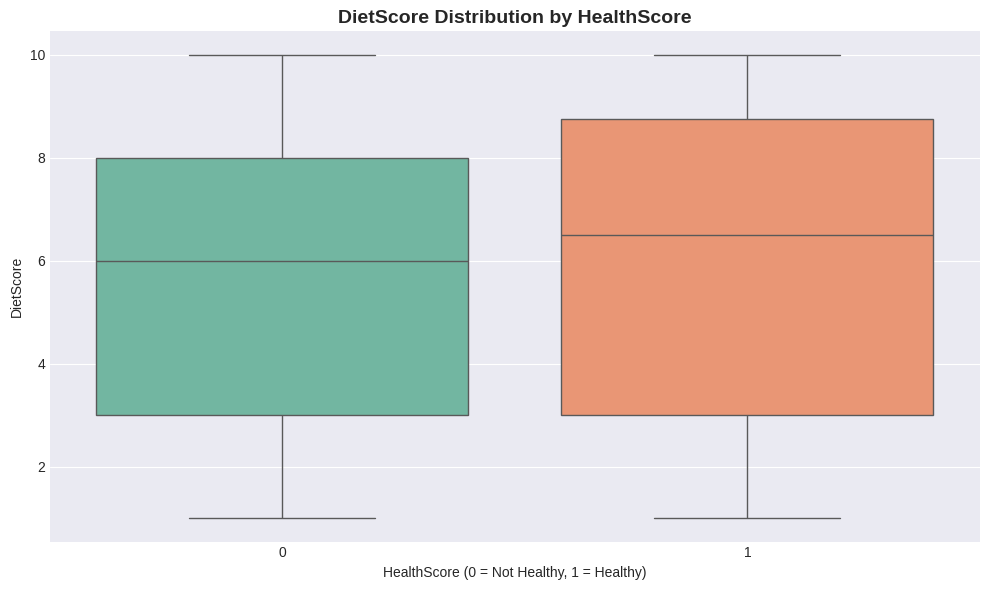

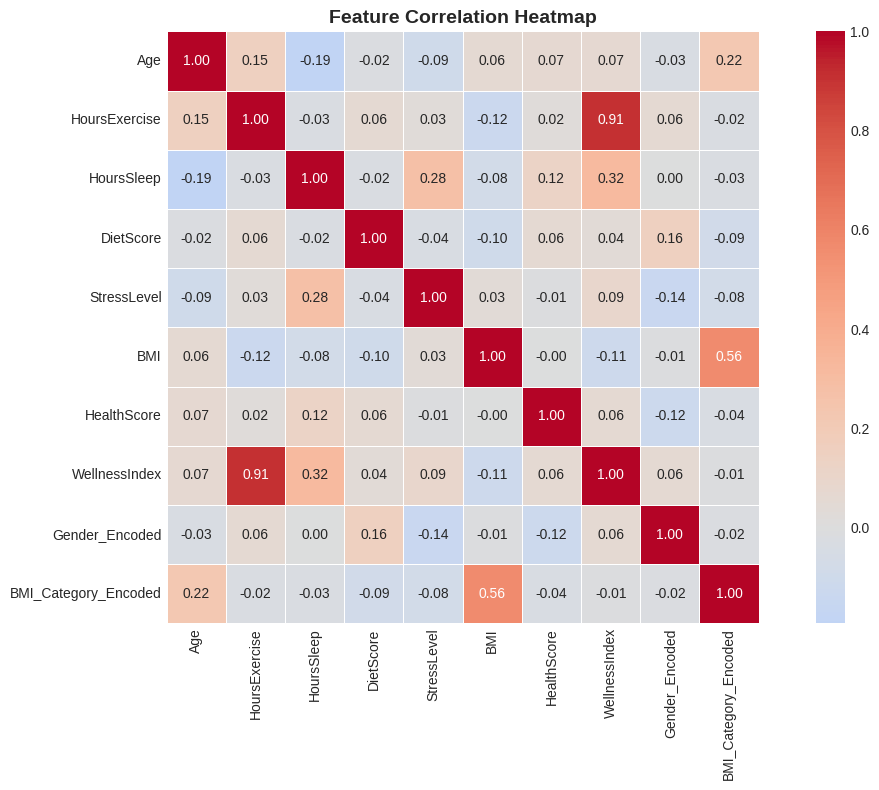

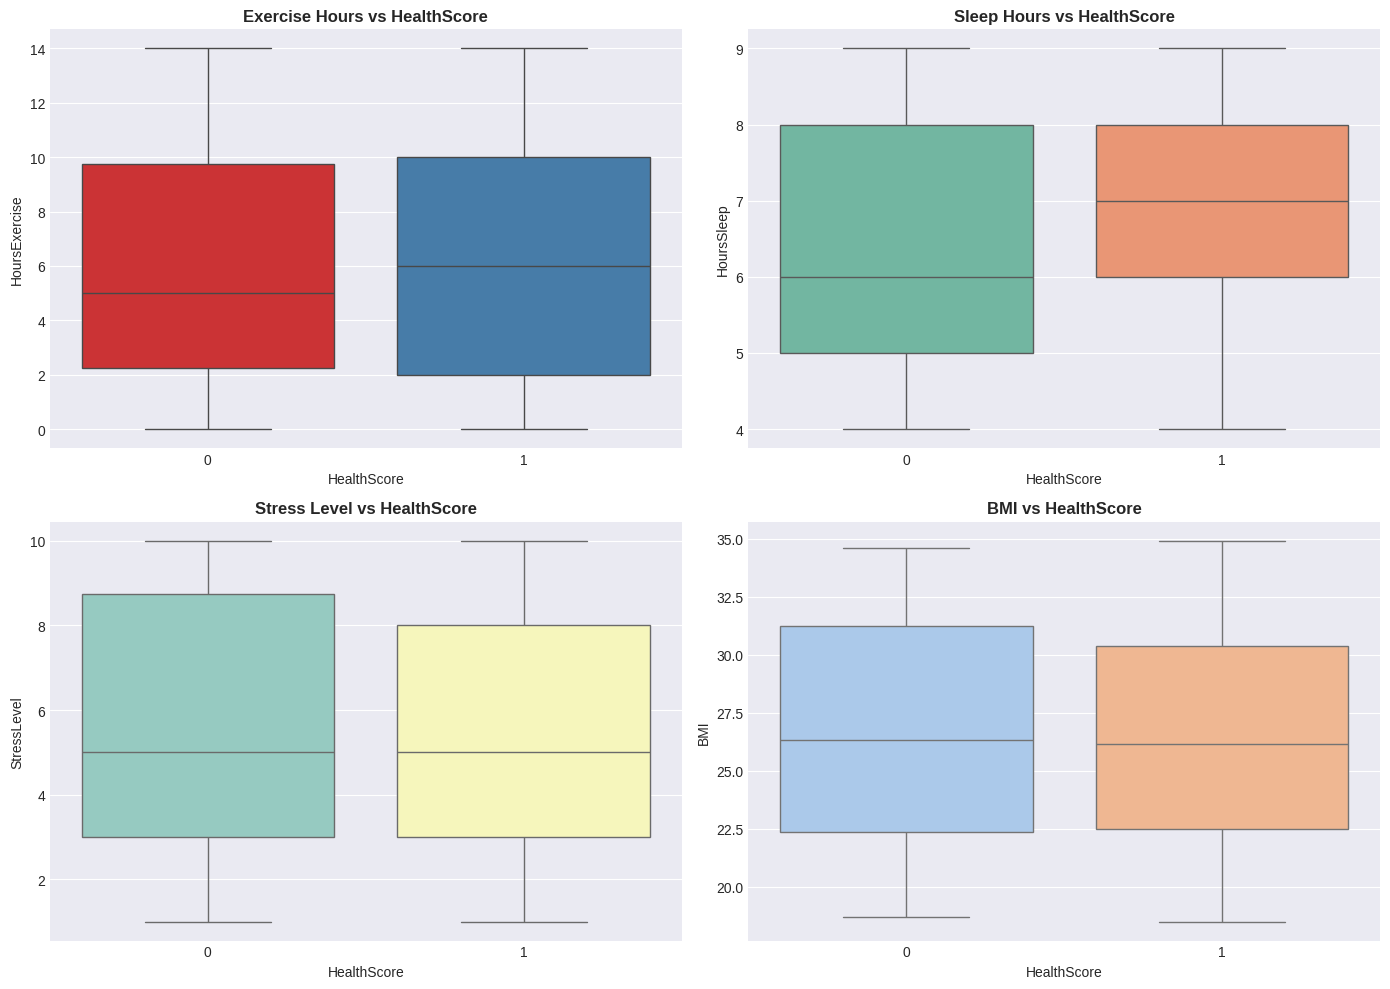

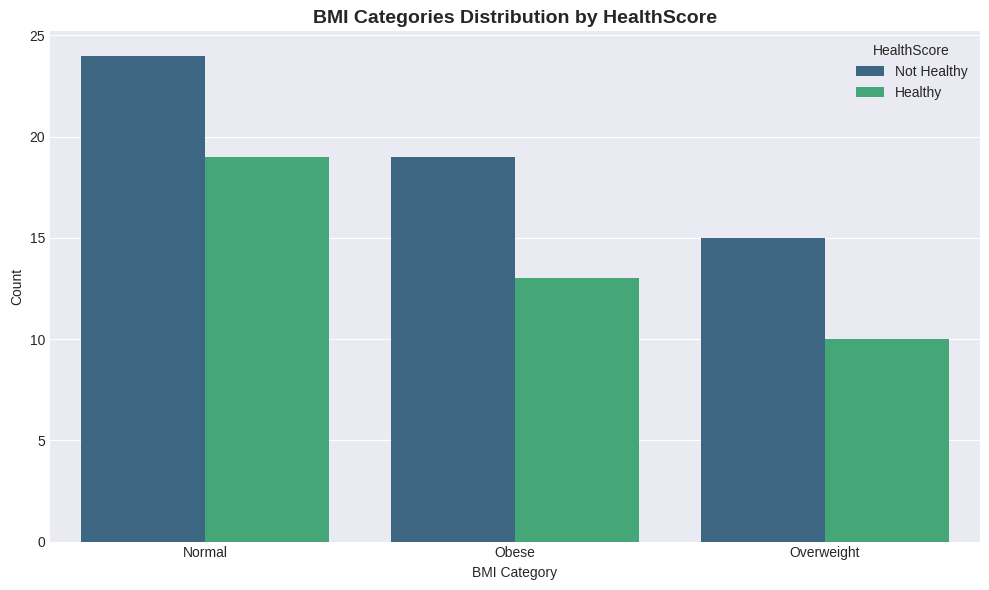

VISUALIZATIONS COMPLETE - Check saved images




In [3]:
# ============================================
# ACTIVITY PART 3 — Data Visualization
# ============================================

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# TODO 10: Histogram of HealthScore
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='HealthScore', bins=20, kde=True, color='steelblue')
plt.title('Distribution of HealthScore', fontsize=14, fontweight='bold')
plt.xlabel('HealthScore (0 = Not Healthy, 1 = Healthy)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('healthscore_distribution.png', dpi=100)
plt.show()

# TODO 11: Scatter plot: WellnessIndex vs HealthScore
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='WellnessIndex', y='HealthScore',
                hue='HealthScore', size='HealthScore', sizes=(50, 200), alpha=0.7)
plt.title('WellnessIndex vs HealthScore', fontsize=14, fontweight='bold')
plt.xlabel('WellnessIndex (Exercise Hours × Sleep Hours)')
plt.ylabel('HealthScore')
plt.tight_layout()
plt.savefig('wellness_vs_health.png', dpi=100)
plt.show()

# TODO 12: Boxplot: DietScore vs HealthScore
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='HealthScore', y='DietScore', palette='Set2')
plt.title('DietScore Distribution by HealthScore', fontsize=14, fontweight='bold')
plt.xlabel('HealthScore (0 = Not Healthy, 1 = Healthy)')
plt.ylabel('DietScore')
plt.tight_layout()
plt.savefig('diet_vs_health.png', dpi=100)
plt.show()

# TODO 13: Heatmap of feature correlations
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numerical_features = ['Age', 'HoursExercise', 'HoursSleep', 'DietScore',
                      'StressLevel', 'BMI', 'HealthScore', 'WellnessIndex',
                      'Gender_Encoded', 'BMI_Category_Encoded']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

# TODO 14: Additional visualizations
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: HoursExercise vs HealthScore
sns.boxplot(data=df, x='HealthScore', y='HoursExercise', ax=axes[0,0], palette='Set1')
axes[0,0].set_title('Exercise Hours vs HealthScore', fontweight='bold')

# Plot 2: HoursSleep vs HealthScore
sns.boxplot(data=df, x='HealthScore', y='HoursSleep', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Sleep Hours vs HealthScore', fontweight='bold')

# Plot 3: StressLevel vs HealthScore
sns.boxplot(data=df, x='HealthScore', y='StressLevel', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Stress Level vs HealthScore', fontweight='bold')

# Plot 4: BMI vs HealthScore
sns.boxplot(data=df, x='HealthScore', y='BMI', ax=axes[1,1], palette='pastel')
axes[1,1].set_title('BMI vs HealthScore', fontweight='bold')

plt.tight_layout()
plt.savefig('additional_visualizations.png', dpi=100)
plt.show()

# Count plot for BMI Categories by HealthScore
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='BMI_Category', hue='HealthScore', palette='viridis')
plt.title('BMI Categories Distribution by HealthScore', fontsize=14, fontweight='bold')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='HealthScore', labels=['Not Healthy', 'Healthy'])
plt.tight_layout()
plt.savefig('bmi_category_health.png', dpi=100)
plt.show()

print("="*60)
print("VISUALIZATIONS COMPLETE - Check saved images")
print("="*60)
print("\n")

DATA SPLIT COMPLETE
Training set size: 80 samples
Test set size: 20 samples


KNN MODEL RESULTS
Accuracy: 0.4500
F1-Score: 0.2667

Confusion Matrix:
[[7 5]
 [6 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.58      0.56        12
           1       0.29      0.25      0.27         8

    accuracy                           0.45        20
   macro avg       0.41      0.42      0.41        20
weighted avg       0.44      0.45      0.44        20



RANDOM FOREST MODEL RESULTS
Accuracy: 0.6000
F1-Score: 0.4286

Confusion Matrix:
[[9 3]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.75      0.69        12
           1       0.50      0.38      0.43         8

    accuracy                           0.60        20
   macro avg       0.57      0.56      0.56        20
weighted avg       0.59      0.60      0.59        20



LOGISTIC REGRESSION MODEL RESULTS


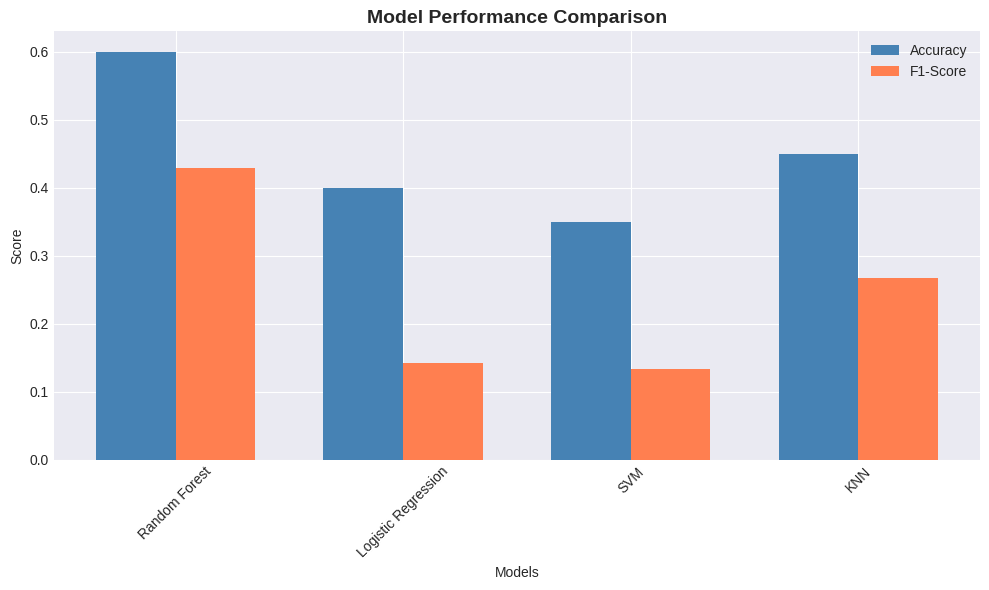

In [4]:
# ============================================
# ACTIVITY PART 4 — Supervised Machine Learning
# ============================================

# TODO 15: Spliting dataset into X (features) and y (HealthScore)
# Selecting features for modeling
feature_cols = ['Age', 'HoursExercise', 'HoursSleep', 'DietScore',
                'StressLevel', 'BMI', 'WellnessIndex', 'Gender_Encoded',
                'BMI_Category_Encoded']
X = df[feature_cols]
y = df['HealthScore']

# TODO 16: Spliting data into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("="*60)
print("DATA SPLIT COMPLETE")
print("="*60)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print("\n")

# TODO 17: Training KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("="*60)
print("KNN MODEL RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
print("\n")

# TODO 18: Training Random Forest, Logistic Regression, and SVM models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'f1_score': f1, 'model': model}

    print("="*60)
    print(f"{name.upper()} MODEL RESULTS")
    print("="*60)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

# Adding KNN to results
results['KNN'] = {'accuracy': accuracy_score(y_test, y_pred_knn),
                  'f1_score': f1_score(y_test, y_pred_knn),
                  'model': knn}

# TODO 19: Comparing models using accuracy and F1-score
print("="*60)
print("MODEL COMPARISON")
print("="*60)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})
print(comparison_df.to_string(index=False))
print("\n")

# Visualizing model comparison
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(comparison_df))
width = 0.35
plt.bar(x_pos - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
plt.bar(x_pos + width/2, comparison_df['F1-Score'], width, label='F1-Score', color='coral')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, comparison_df['Model'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

NEURAL NETWORK ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)



Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.4000 - loss: 0.7489 - val_accuracy: 0.4500 - val_loss: 0.7047
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4625 - loss: 0.7474 - val_accuracy: 0.4000 - val_loss: 0.6959
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4250 - loss: 0.7196 - val_accuracy: 0.4000 - val_loss: 0.6906
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4125 - loss: 0.7278 - val_accuracy: 0.4000 - val_loss: 0.6865
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4750 - loss: 0.7160 - val_accuracy: 0.5000 - val_loss: 0.6837
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4750 - loss: 0.6795 - val_accuracy: 0.6500 - val_loss: 0.6817
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5750 - loss: 0.6977 - val_accuracy: 0.6500 - val_loss: 0.6805
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5000 - loss: 0.7110 - val_accuracy: 0.6500 - val_loss: 0.68

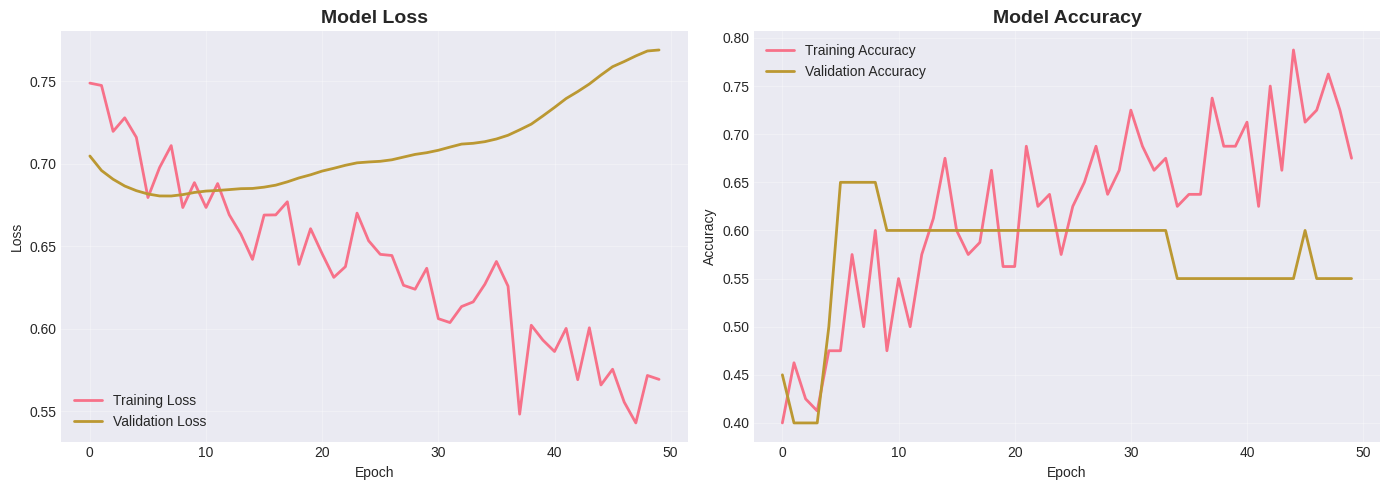

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
NEURAL NETWORK RESULTS
Accuracy: 0.5500
F1-Score: 0.1818

Confusion Matrix:
[[10  2]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.83      0.69        12
           1       0.33      0.12      0.18         8

    accuracy                           0.55        20
   macro avg       0.46      0.48      0.44        20
weighted avg       0.49      0.55      0.49        20





In [5]:
# ============================================
# ACTIVITY PART 5 — Neural Network Programming
# ============================================

# TODO 20: Standardizing features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TODO 21: Building a simple feedforward neural network
model_nn = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiling the model
model_nn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("="*60)
print("NEURAL NETWORK ARCHITECTURE")
print("="*60)
model_nn.summary()
print("\n")

# TODO 22: Training network on training data, validate on test data
history = model_nn.fit(X_train_scaled, y_train,
                       epochs=50,
                       batch_size=32,
                       validation_data=(X_test_scaled, y_test),
                       verbose=1)

# TODO 23: Plotting loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neural_network_training.png', dpi=100)
plt.show()

# TODO 24: Evaluating predictions using confusion matrix
y_pred_nn = (model_nn.predict(X_test_scaled) > 0.5).astype(int)
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

print("="*60)
print("NEURAL NETWORK RESULTS")
print("="*60)
print(f"Accuracy: {nn_accuracy:.4f}")
print(f"F1-Score: {nn_f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))
print("\n")